## Notebook Objectives
 - Load a model from the checkpoint file
 - plot the loss functions
 - plot the latent dimensions
 - GMM to latent dimensions
 - Analysis of RMSD, RMTD, Potential, Repulsion on:
   - Test Set
   - Decoded Test Set
   - GMM'ed Set

In [1]:
from typing import Optional, Any
import shutil, os, jax, flax, optax, json, matplotlib, glob
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
from jax import random, numpy as jnp
#from pyscripts.Maths import Maths
#from pyscripts.NN_models import *
from flax import linen as nn
from flax.training import checkpoints, train_state
from flax import struct, serialization
import orbax.checkpoint
import mdtraj as md
#from pyscripts.AutoEncoder_Experiment import AutoEncoder_Experiment

2024-03-27 22:07:35.000285: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [ ]:
class Experiment_Analyzer():
    def __init__(self, json_info, netcdf_fn, chkpt_fn):
        if type(json_info) is str:
            with open(json_info, 'r') as f:
                self.json_params = json.load(f)
        elif type(json_info) is dict:
            self.json_params = json_info
        else:
            raise Exception('json_info should be a string (to load the file) or dict (if the file is loaded already)')
        #Files
        fname_dcd = self.json_params["files"]["fname_dcd"]
        fname_prmtop = self.json_params["files"]["fname_prmtop"]
        save_dir = self.json_params["files"]["save_dir"]
        self.math = Maths(fname_prmtop)
        self.model_name = self.json_params["model"]["model_name"]
        model_dir = os.path.join(save_dir, f'{self.model_name}/')
        self.n_latents = self.json_params["training"]["arch"]["latent_dim"]
        activators = self.json_params["training"]["arch"]["activators"]
        layer_ops = self.json_params["training"]["arch"]["layer_ops"]
        dropout_rates = self.json_params["training"]["arch"]["dropout_rates"]
        self.batch_size = self.json_params["training"]["arch"]["batch_size"]
        learning_rate = self.json_params["training"]["arch"]["learning_rate"]
        test_slice = self.json_params["training"]["data"]["test_slice"]
        rng_key = self.json_params["training"]["arch"]["rng_key"]
        
        if self.json_params["files"]["data_dir"] == 'None':
            latent_dir = os.path.join(model_dir, f'{self.n_latents:02d}_latents/')
            self.data_dir = os.path.join(latent_dir, f'rpt_{test_slice}/')
        else:
            self.data_dir = self.json_params["files"]["data_dir"]
        
        #Test and Train Data
        data_start = self.json_params["training"]["data"]["data_slice_start"]
        data_end = self.json_params["training"]["data"]["data_slice_end"]
        if data_end == 'None':
            data_end = None
        
        
        
        #Load and Align
        c = md.load(fname_dcd, top=fname_prmtop)
        c = c.superpose(c) # FEED IN ALIGNED DATA
        coord_set = jnp.array(c.xyz.reshape(c.xyz.shape[0], -1))[data_start:data_end] # reshape to be n_conf, 3*n_atom 
        num_samples, input_size = coord_set.shape

        #Make test and train sets - indices, then sets
        test_indices = np.array(range(test_slice, num_samples, 5)) #every fifth frame
        train_indices = np.array([element for element in range(num_samples) if element not in test_indices])
        self.test_data = coord_set[test_indices]
        self.train_data = coord_set[train_indices]
        print(self.train_data.shape, self.test_data.shape)
        
        #Set Test and Train data into batches - Train
        num_train = self.train_data.shape[0]
        num_complete_batches, leftover = divmod(num_train, self.batch_size)
        self.num_train_batches = num_complete_batches + bool(leftover)
        self.train_batches = DataStream(self.n_latents, num_train, self.num_train_batches, self.batch_size, self.train_data)
        
        #Set Test and Train data into batches - Test
        num_test = self.test_data.shape[0]
        num_complete_batches, leftover = divmod(num_test, self.batch_size)
        self.num_test_batches = num_complete_batches + bool(leftover)
        self.test_batches = DataStream(self.n_latents, num_test, self.num_test_batches, self.batch_size, self.test_data)

        self.nc = nc.Dataset(netcdf_fn, 'r')
        
        if self.json_params["training"]["arch"]["hidden_layers"] != "Auto":
            hidden_layers = self.json_params["training"]["arch"]["hidden_layers"]
        else:
            hidden_layers = [input_size]*3
        
        activators = [eval(activator) for activator in activators]
        layer_ops = [eval(layer_op) for layer_op in layer_ops]
        self.model = AutoEncoder(input_size=input_size, n_latents=self.n_latents,
                                 hidden_layers=hidden_layers, activators=activators,
                                 layer_ops=layer_ops, dropout_rates=dropout_rates)
        rng_init = jax.random.PRNGKey(rng_key)
        rng, key = jax.random.split(rng_init)
        self.state = train_state.TrainState.create(apply_fn=self.model.apply,
                                                   params=self.model.init(key, coord_set, rng)['params'],
                                                   tx=optax.adam(learning_rate=learning_rate))
        orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        self.state = orbax_checkpointer.restore(chkpt_fn, item=self.state)

    def plot_losses(self):
        traingrp = self.nc.groups['Train']
        testgrp = self.nc.groups['Test']
        for foo in ['RMSD', 'RMTD', 'Potential', 'Repulsion']:
            plt.clf()
            plt.title(foo)
            if foo != 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :, :], axis=(1, 2)))
            elif foo == 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :], axis=(1)))
            plt.xlabel('Epoch')
            plt.yscale('log')
            if foo == 'RMSD':
                plt.ylabel('RMSD (nm)')
            elif foo == 'RMTD':
                plt.ylabel('RMTD (rad)')
            elif foo == 'Potential':
                plt.ylabel('Potential (kJ/mol)')
            plt.show()

### Load the Analyzer

In [ ]:
json_fn = 'Bridges2_Runs/02_24_24/Test_3MP/Test_3MP_16_2.json'
netcdf_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/model_Test_3MP_16.nc'
ckpt_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/checkpoint_managed/3999/default/'
#the json is from bridges, change file paths to be from jetstream
#/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
with open(json_fn, 'r') as f:
    json_params = json.load(f)

for filetype in ["fname_dcd", "fname_prmtop", "save_dir"]:
    json_params['files'][filetype] = json_params['files'][filetype].replace("/ocean/projects/mcb160011p/josephdb/",
                                                                            "/media/volume/sdb/")
self = Experiment_Analyzer(json_params, netcdf_fn, ckpt_fn)

In [ ]:
print(self.nc)
print(self.state.apply_fn)
print(self.math.ener_fun)

In [ ]:
self.nc.groups['Train']

In [2]:
nc_files = sorted(glob.glob('bridges2_runs/model_AE_Drop*checkpoint.nc'))
for file in nc_files:
    print(file)

bridges2_runs/model_AE_Dropout_RMSD_only_002_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_004_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_008_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_016_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_032_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_064_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_128_checkpoint.nc
bridges2_runs/model_AE_Dropout_RMSD_only_256_checkpoint.nc


In [10]:
def plot_results(filename, print_only=False):
    print(filename)
    dataset = nc.Dataset(filename, 'r')    
    parts = filename.split('_')
    num_latents = parts[-2]
    
    traingrp = dataset.groups['Train']
    testgrp = dataset.groups['Test']
    if not print_only:
        for foo in ['RMSD', 'Potential']:
            plt.clf()
            plt.title(foo + f' {num_latents} Latents')
            for grp in [traingrp, testgrp]:
                _ = plt.plot(np.arange(grp.variables[foo][:, :].shape[0]),
                             np.mean(grp.variables[foo][:, :], axis=1))
            plt.xlabel('Epoch')
            if foo == 'Potential':
                plt.yscale('log')
            
            if foo == 'RMSD':
                plt.ylabel('RMSD (nm)')
            elif foo == 'Potential':
                plt.ylabel('Potential (kJ/mol)')
            plt.legend(['Train','Test'])
            plt.show()
    
    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')
    print(f'Last PotDiff (% Deviation): Train: {np.mean(traingrp.variables['Potential'][-1, :])} Test {np.mean(testgrp.variables['Potential'][-1, :])}')
    dataset.close()

In [25]:
def plot_multiple_ncs(filenames, title):
    latents = []
    last_rmsds = []
    last_potentials = []
    
    for file in filenames:
        parts = file.split('_')
        num_latents = parts[-2]
        latents.append(int(num_latents))
        dc = nc.Dataset(file)
        last_rmsds.append([np.mean(dc['Train']['RMSD'][-1,:]), np.mean(dc['Test']['RMSD'][-1,:])])
        last_potentials.append([np.mean(dc['Train']['Potential'][-1,:]), np.mean(dc['Test']['Potential'][-1,:])])
        dc.close()
    latents = np.array(latents)
    last_rmsds = np.array(last_rmsds)
    last_potentials = np.array(last_potentials)
    
    plt.clf()
    plt.title(title)
    for i in [0, 1]:
        _ = plt.scatter(latents, last_rmsds[:, i])
    plt.ylabel('RMSD (nm)')
    plt.xlabel('Num Latent Dimensions')
    plt.xscale('log')
    plt.legend(["Train", "Test"])
    plt.show()

    plt.clf()
    plt.title(title)
    for i in [0, 1]:
        _ = plt.scatter(latents, np.sqrt(last_potentials[:, i]))
    plt.ylabel('Potential (% dev)')
    plt.yscale('log')
    plt.xlabel('Num Latent Dimensions')
    plt.xscale('log')
    plt.legend(["Train", "Test"])
    plt.show()

bridges2_runs/model_AE_Dropout_RMSD_only_002_checkpoint.nc


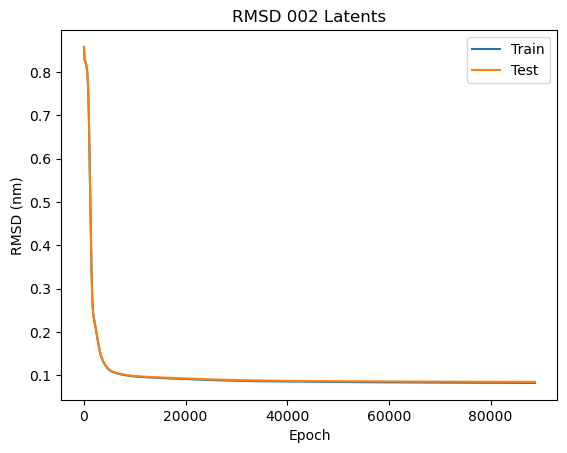

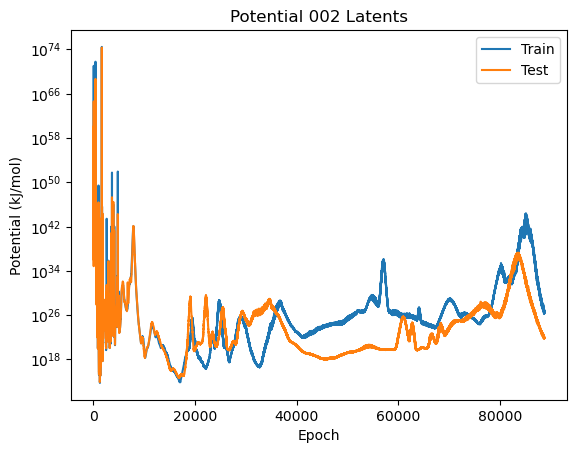

Num Epochs 88700
Last RMSD (nm): Train: 0.08267097920179367 Test 0.08508706837892532
Last PotDiff (% Deviation): Train: 5.482619869459473e+26 Test 9.855488128703321e+21
bridges2_runs/model_AE_Dropout_RMSD_only_004_checkpoint.nc


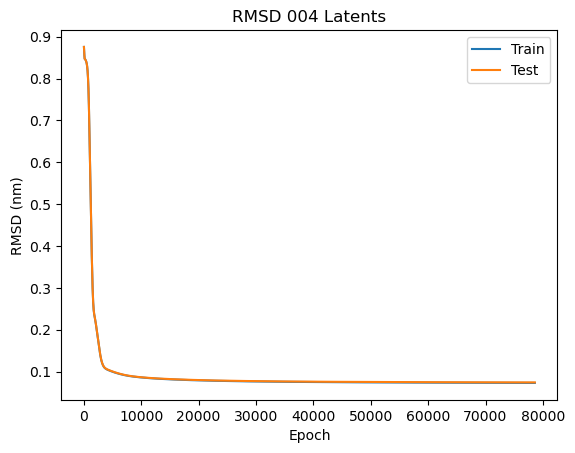

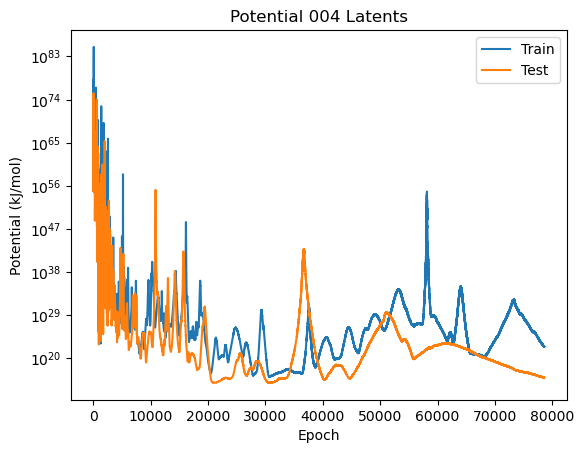

Num Epochs 78600
Last RMSD (nm): Train: 0.07272383570671082 Test 0.07395801693201065
Last PotDiff (% Deviation): Train: 2.2415411697260022e+22 Test 8390902651437286.0
bridges2_runs/model_AE_Dropout_RMSD_only_008_checkpoint.nc


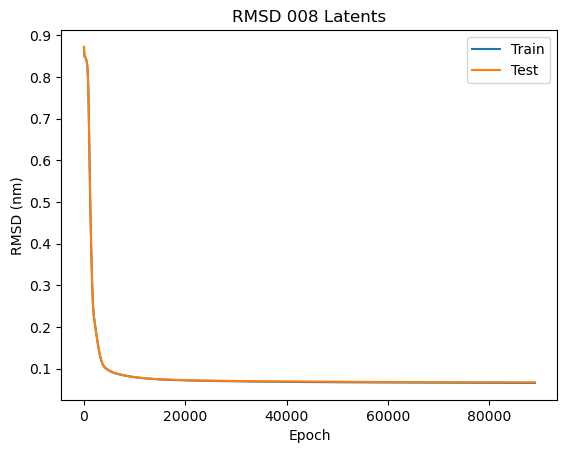

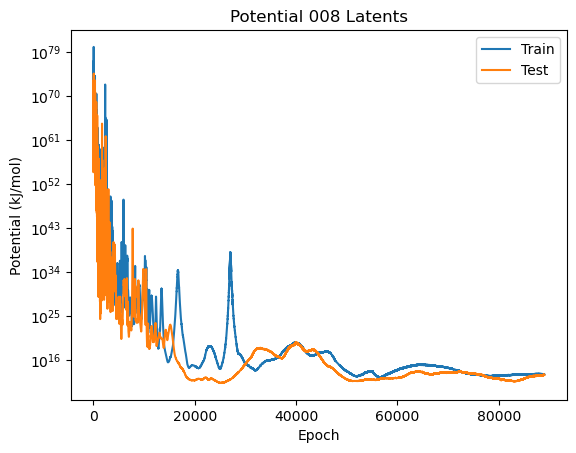

Num Epochs 89000
Last RMSD (nm): Train: 0.06584832817316055 Test 0.06742168962955475
Last PotDiff (% Deviation): Train: 11236876405644.592 Test 8067973093653.438
bridges2_runs/model_AE_Dropout_RMSD_only_016_checkpoint.nc


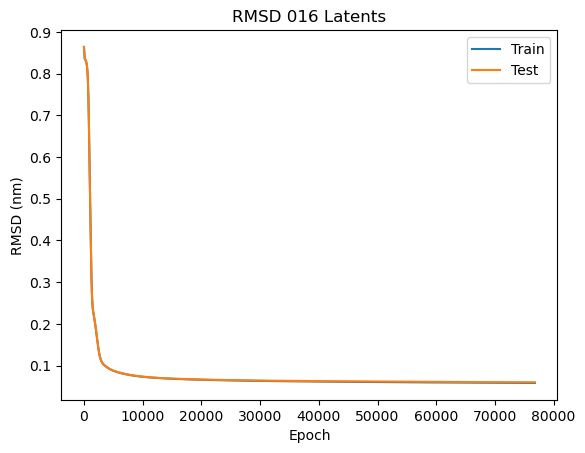

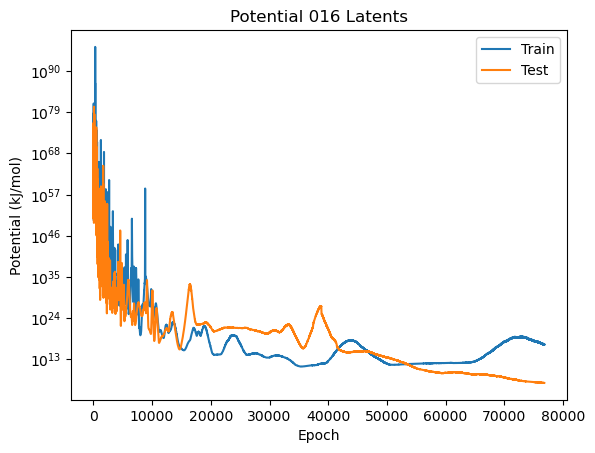

Num Epochs 76800
Last RMSD (nm): Train: 0.05826260522007942 Test 0.05982368439435959
Last PotDiff (% Deviation): Train: 8.723295793612299e+16 Test 4872092.3678940665
bridges2_runs/model_AE_Dropout_RMSD_only_032_checkpoint.nc


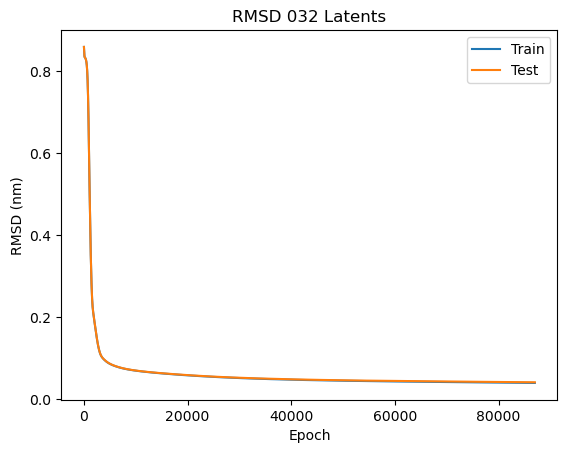

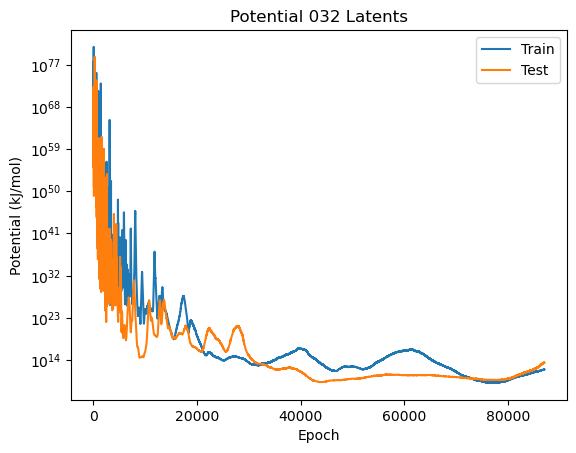

Num Epochs 87000
Last RMSD (nm): Train: 0.03923758864402771 Test 0.040808092802762985
Last PotDiff (% Deviation): Train: 1038618207672.5762 Test 26037947300357.137
bridges2_runs/model_AE_Dropout_RMSD_only_064_checkpoint.nc


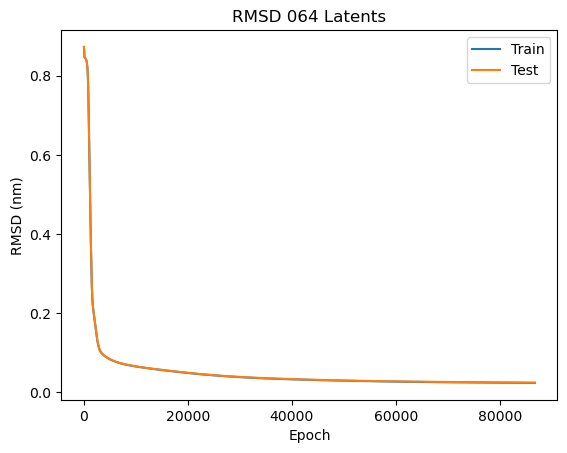

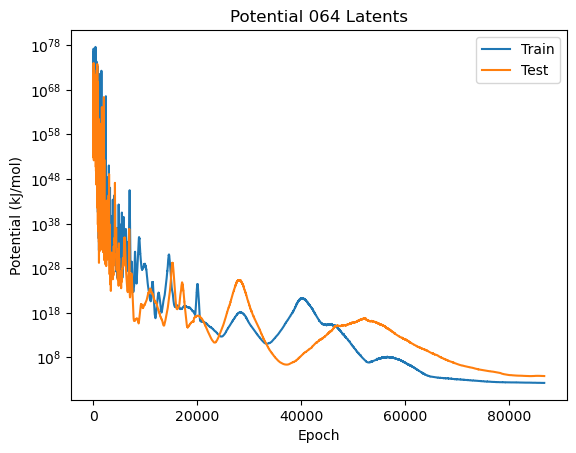

Num Epochs 86700
Last RMSD (nm): Train: 0.023829080164432526 Test 0.02460385300219059
Last PotDiff (% Deviation): Train: 193.6959577176196 Test 6630.874047502657
bridges2_runs/model_AE_Dropout_RMSD_only_128_checkpoint.nc


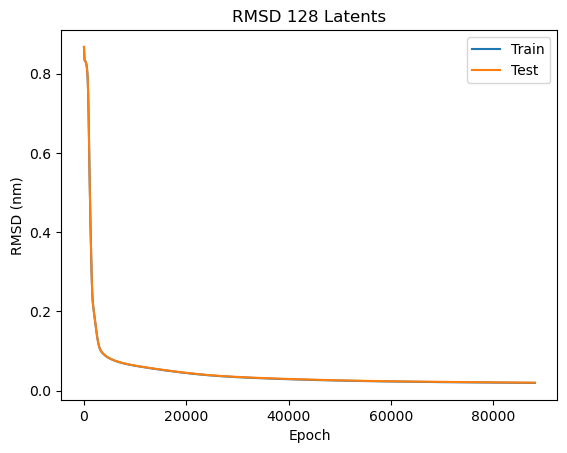

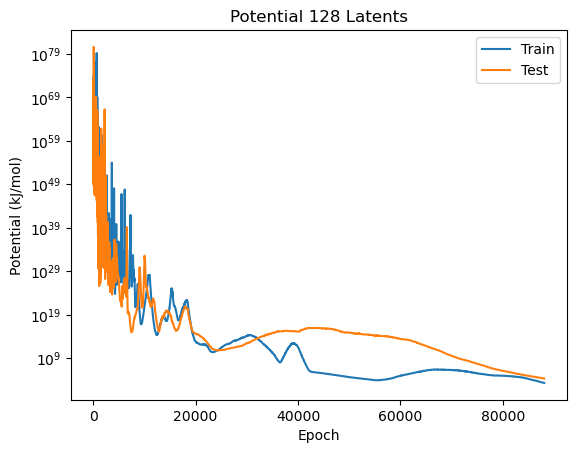

Num Epochs 88100
Last RMSD (nm): Train: 0.019203927367925644 Test 0.019855979830026627
Last PotDiff (% Deviation): Train: 2307.2587008814326 Test 23563.262477041197
bridges2_runs/model_AE_Dropout_RMSD_only_256_checkpoint.nc


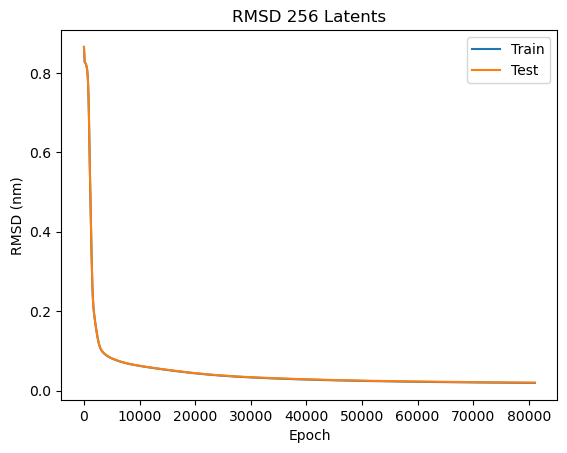

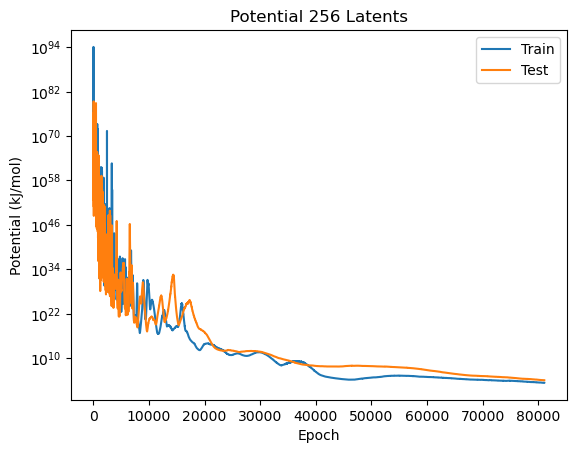

Num Epochs 81100
Last RMSD (nm): Train: 0.01910475268959999 Test 0.01986311562359333
Last PotDiff (% Deviation): Train: 1926.625086162663 Test 10142.569512866137


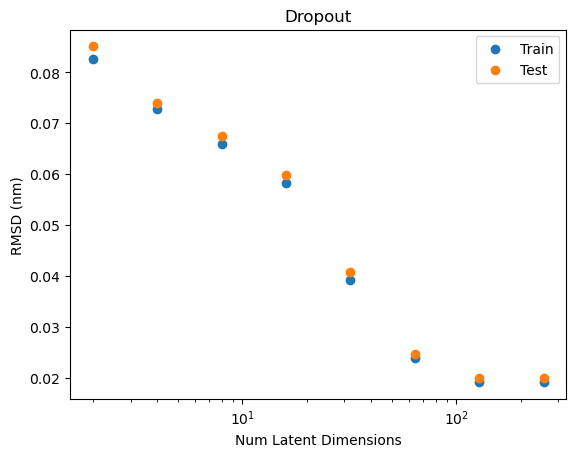

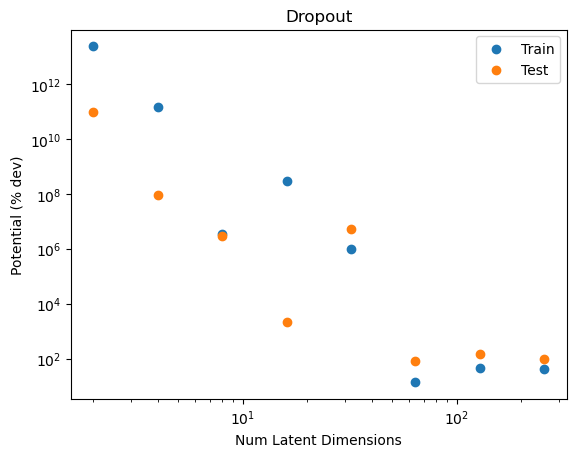

In [27]:
for file in nc_files:
    plot_results(file)
plot_multiple_ncs(nc_files, 'Dropout')

In [ ]:
nc_files = [element for element in sorted(glob.glob('bridges2_runs/model_AE_NO_Drop*.nc')) if "checkpoint" in element]
for file in nc_files:
    print(file)

In [ ]:
for file in nc_files:
    try:
        plot_results(file, print_only=True)
    except:
        print(file, 'ERROR')

In [ ]:
plot_multiple_ncs(nc_files, 'No Dropout')

In [ ]:
orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
state = orbax_checkpointer.restore('AE_Dropout_RMSD_only/64_latents/rpt_1/checkpoint_managed/23766/default/')

In [ ]:
state.apply_fn

### Plot the Loss

In [ ]:
self.plot_losses()

### Plot the Latents

In [ ]:
rng_seed = 8925
rng = jax.random.PRNGKey(rng_seed)
rng, key = jax.random.split(rng)
decoded, latent = self.state.apply_fn({'params':self.state.params}, self.test_data, rng)

In [ ]:
for i in range(self.n_latents):
    plt.clf()
    _ = plt.hist(latent[:, i], bins=50)
    plt.title(f'Latent {i}')
    plt.show()

In [ ]:
fig, axs = plt.subplots(self.n_latents, self.n_latents,
                        figsize=(15, 10), sharex='col')
for i in range(self.n_latents):
    for j in range(self.n_latents):
        #axs[i,j].scatter(latent[:,j], latent[:,i])
        if i > j:
            axs[i,j].scatter(latent[:,j], latent[:,i])
        elif i == j:
            axs[i,j].hist(latent[:, i], bins=25)


### Gaussian Mixture Model

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
ics = []
X = np.array(latent)
for i in range(1, 31):
    MM = GaussianMixture(n_components=i).fit(latent)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [ ]:
MM = GaussianMixture(n_components=5).fit(X) #chosen based on above graph
samples = MM.sample(latent.shape[0])[0]

In [ ]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latent[:,i], bins=25, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

### Plot Energies

In [ ]:
test_ener = self.math.ener_fun(self.test_data)
decoded_ener = self.math.ener_fun(decoded)
gmm_atomistic = self.state.apply_fn({'params': self.state.params}, samples, rng, method=self.model.decode)
gmm_ener = self.math.ener_fun(gmm_atomistic)

In [ ]:
plt.clf()
_ = plt.hist(test_ener, bins=25)
plt.show()
thresh = 7e6
_ = plt.hist(decoded_ener[decoded_ener < thresh], bins=25, histtype='step')
_ = plt.hist(gmm_ener[gmm_ener < thresh], bins=25, histtype='step')

### Distance Matrics

#### Test Data

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(self.test_data, self.test_data))

#### Decoded Test Data

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(decoded, decoded))

#### Decoded Gaussian Mixture Model

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(gmm_atomistic, gmm_atomistic))